In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('./spam-classifier dataset/spam.csv', encoding='latin-1')

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("Dataset shape:", df.shape)
print("First 5 rows of the dataset:")
print(df.head())

Dataset shape: (5572, 2)
First 5 rows of the dataset:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [7]:
print("Label distribution:")
print(df['label'].value_counts())

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [8]:
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

In [9]:
X = df['message']
y = df['label_encoded']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining samples: {X_train}")
print(f"Testing samples: {X_test}")


Training samples: 1978    No I'm in the same boat. Still here at my moms...
3989    (Bank of Granite issues Strong-Buy) EXPLOSIVE ...
3935       They r giving a second chance to rahul dengra.
4078       O i played smash bros  &lt;#&gt;  religiously.
4086    PRIVATE! Your 2003 Account Statement for 07973...
                              ...                        
3772    I came hostel. I m going to sleep. Plz call me...
5191                               Sorry, I'll call later
5226        Prabha..i'm soryda..realy..frm heart i'm sory
5390                           Nt joking seriously i told
860                   In work now. Going have in few min.
Name: message, Length: 4457, dtype: object
Testing samples: 3245    Funny fact Nobody teaches volcanoes 2 erupt, t...
944     I sent my scores to sophas and i had to do sec...
1044    We know someone who you know that fancies you....
2484    Only if you promise your getting out as SOON a...
812     Congratulations ur awarded either å£500 of 

In [11]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [12]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [13]:
y_pred = model.predict(X_test_tfidf)

In [23]:
accuracy= accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Ham', 'Spam'])

print(f"\n Accuracy: {accuracy:.4f} %")
print(f" Precision: {precision:.4f} %")
print(f" Recall: {recall:.4f} %")
print(f" F1-Score: {f1:.4f} %")
print("\n Classification Report:")
print(report)


 Accuracy: 0.9731 %
 Precision: 1.0000 %
 Recall: 0.8000 %
 F1-Score: 0.8889 %

 Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       965
        Spam       1.00      0.80      0.89       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



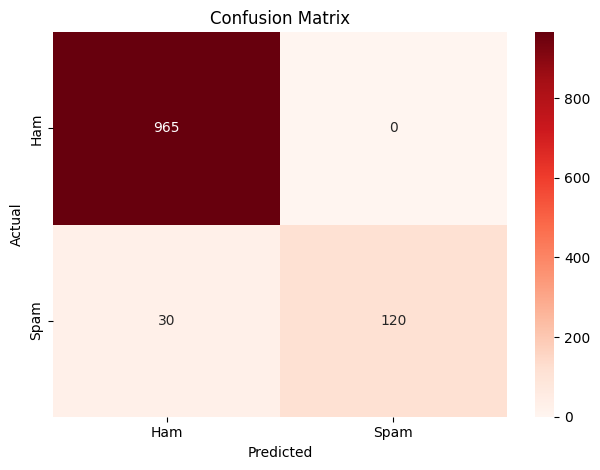

In [21]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Ham', 'Spam'], 
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [18]:
def predict_spam(message):
    vec = vectorizer.transform([message])
    result = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    label = "🚨 SPAM" if result == 1 else "✅ HAM (Not Spam)"
    print(f"\nMessage : {message}")
    print(f"Result  : {label}")
    print(f"Confidence → Ham: {prob[0]:.2%} | Spam: {prob[1]:.2%}")

In [19]:
predict_spam("Congratulations! You've won a free iPhone. Click here now!")
predict_spam("Hey, are we still meeting tomorrow at 3pm?")
predict_spam("URGENT: Your bank account has been suspended. Verify now.")


Message : Congratulations! You've won a free iPhone. Click here now!
Result  : 🚨 SPAM
Confidence → Ham: 46.76% | Spam: 53.24%

Message : Hey, are we still meeting tomorrow at 3pm?
Result  : ✅ HAM (Not Spam)
Confidence → Ham: 99.63% | Spam: 0.37%

Message : URGENT: Your bank account has been suspended. Verify now.
Result  : ✅ HAM (Not Spam)
Confidence → Ham: 57.17% | Spam: 42.83%
